# Assignment 1, Task B: Regression using tree methods - Solved

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Descriptors

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
df = pd.read_csv("esol.csv")
df.head()

,SMILES,label
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77
1,Cc1occc1C(=O)Nc2ccccc2,-3.30
2,CC(C)=CCCC(C)=CC(=O),-2.06
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87
4,c1ccsc1,-1.33


## 1. Inspect and clean the data
Gain some overview of the data and assess NaNs and duplicates and clean if needed.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SMILES  1128 non-null   object 
 1   label   1128 non-null   float64
dtypes: float64(1), object(1)
memory usage: 17.8+ KB
None

Missing values:
 SMILES    0
label     0
dtype: int64

Duplicates: 0


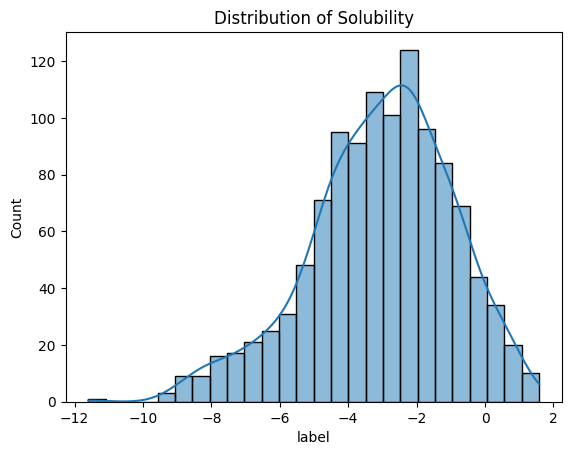

In [9]:
# Gain overview
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

# Basic cleaning
df = df.drop_duplicates()
df = df.dropna()

# Check distribution of the target variable (assuming 'measured log solubility in mols per litre')
sns.histplot(df.iloc[:, -1], kde=True)
plt.title("Distribution of Solubility")
plt.show()

## 2. Create molecular descriptors from the Smiles
Use the snippet below to calculate descriptors from the SMILES strings. Make sure to include the molecular weight, the logP and choose three more which you believe to impact the solubility, e.g. https://greglandrum.github.io/rdkit-blog/posts/2022-12-23-descriptor-tutorial.html or here: https://deepwiki.com/rdkit/rdkit/6.1-molecular-descriptors-and-properties 

In [11]:
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return pd.Series({
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "NumHDonors": Descriptors.NumHDonors(mol),
        "NumHAcceptors": Descriptors.NumHAcceptors(mol),
        "TPSA": Descriptors.TPSA(mol)
    })

# Apply to dataframe
descriptor_df = df["SMILES"].apply(compute_descriptors) # Ensure 'smiles' column name matches your df

# Combine descriptors with original data
df_full = pd.concat([df, descriptor_df], axis=1)

# Remove rows where descriptor calculation failed
df_full = df_full.dropna()
df_full.head()

,SMILES,label,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77,457.432,-3.10802,7.0,12.0,202.32
1,Cc1occc1C(=O)Nc2ccccc2,-3.30,201.225,2.84032,1.0,2.0,42.24
2,CC(C)=CCCC(C)=CC(=O),-2.06,152.237,2.87800,0.0,1.0,17.07
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87,278.354,6.29940,0.0,0.0,0.00
4,c1ccsc1,-1.33,84.143,1.74810,0.0,1.0,0.00


## 3. Create the feature matrix and target vector

In [12]:
# Features: The 5 descriptors created
X = df_full[["MolWt", "LogP", "NumHDonors", "NumHAcceptors", "TPSA"]]

y = df_full.iloc[:, 1] # Based on standard ESOL format, usually index 1 or -1

## 4. Train the models
Use a classic train-test split of 0.2 including a random seed. For training and predicting labels, take note of the time the process takes for each model (does not necessarily have to be coded, can also be estimated). Make sure to predict labels for both training and test splits in order to identify overfitting. Use the RMSE and R2 as metrics for evaluation of the baseline performance of the models. Make sure to consider overfitting.

In [13]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    # Training
    model.fit(X_train, y_train)
    
    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Evaluation
    rmse_train = np.sqrt(mean_squared_error(y_train, train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, test_pred))
    r2_train = r2_score(y_train, train_pred)
    r2_test = r2_score(y_test, test_pred)
    
    results[name] = {"RMSE_Train": rmse_train, "RMSE_Test": rmse_test, "R2_Train": r2_train, "R2_Test": r2_test}
    
    print(f"--- {name} ---")
    print(f"Train R2: {r2_train:.3f}, Test R2: {r2_test:.3f}")
    print(f"Train RMSE: {rmse_train:.3f}, Test RMSE: {rmse_test:.3f}\n")

# Best model selection (usually GradientBoosting or RandomForest)
best_model_name = max(results, key=lambda k: results[k]['R2_Test'])
print(f"Best performing model: {best_model_name}")

--- DecisionTree ---
Train R2: 0.996, Test R2: 0.742
Train RMSE: 0.129, Test RMSE: 1.105

--- RandomForest ---
Train R2: 0.981, Test R2: 0.850
Train RMSE: 0.284, Test RMSE: 0.841

--- GradientBoosting ---
Train R2: 0.936, Test R2: 0.844
Train RMSE: 0.527, Test RMSE: 0.858

Best performing model: RandomForest


Use the best model and plot the predictions over the true values (y_test vs. y_pred) in a scatterplot.

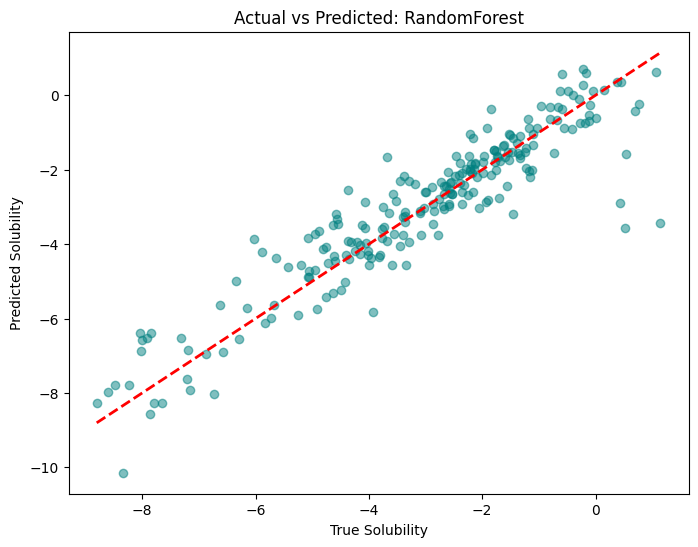

In [14]:
best_model_instance = models[best_model_name]
y_pred = best_model_instance.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("True Solubility")
plt.ylabel("Predicted Solubility")
plt.title(f"Actual vs Predicted: {best_model_name}")
plt.show()

## 5. Hyperparameter tuning of the best model
Use GridSearchCV to optimise the hyperparameters for the best model. Use a reasonable parameter grid (2-3 different values max. for each parameter you want to optimise).

In [15]:
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Run Grid Search
grid_search = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Evaluate tuned model
best_model = grid_search.best_estimator_
tuned_pred = best_model.predict(X_test)
print(f"Tuned Test R2: {r2_score(y_test, tuned_pred):.3f}")

Tuned Test R2: 0.848


Extract the best model

In [ ]:
best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


Useful tool: Export (and reimport) your best model:

In [ ]:
import joblib
# export the best model:
joblib.dump(best_model, "best_model.joblib")
# reload the best model:
loaded_model = joblib.load("best_model.joblib")

Evaluate the best model on the test set.

In [ ]:
y_pred_tuned = best_model.predict(X_test)

rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Final Test RMSE: {rmse_tuned:.4f}")
print(f"Final Test R2 Score: {r2_tuned:.4f}")

Final Test RMSE: 0.8484
Final Test R2 Score: 0.8477


Plot the predicted vs. the true solubility again!

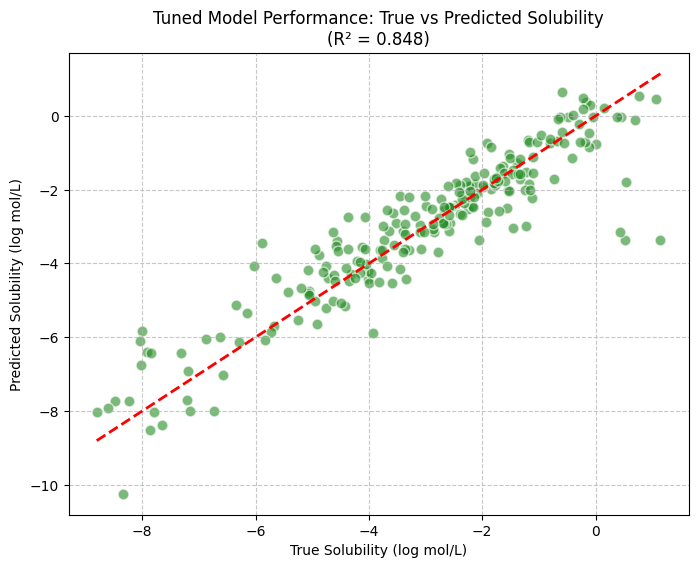

In [ ]:
plt.figure(figsize=(8, 6))

# Scatter plot of actual vs predicted values
plt.scatter(y_test, y_pred_tuned, alpha=0.6, color='forestgreen', edgecolors='w', s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)

# Labels and title
plt.xlabel('True Solubility (log mol/L)')
plt.ylabel('Predicted Solubility (log mol/L)')
plt.title(f'Tuned Model Performance: True vs Predicted Solubility\n(R² = {r2_tuned:.3f})')
plt.grid(True, linestyle='--', alpha=0.7)

# Save the plot
plt.savefig("tuned_solubility_comparison.png")

## 6. Feature importance
Investigate the feature importance for your best model using the snippet below (but with your descriptors).

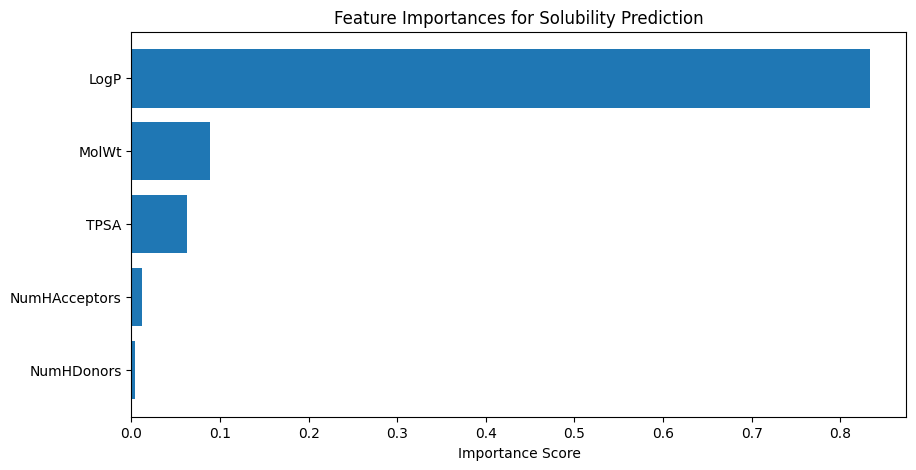

In [ ]:
feature_names = ["MolWt", "LogP", "NumHDonors", "NumHAcceptors", "TPSA"]
importances = best_model.feature_importances_

# Visualization
plt.figure(figsize=(10, 5))
sorted_idx = np.argsort(importances)
plt.barh([feature_names[i] for i in sorted_idx], importances[sorted_idx])
plt.xlabel("Importance Score")
plt.title("Feature Importances for Solubility Prediction")
plt.show()

## 7. Conclusion and discussion
- Which model performed the best?
- Which model showed the worst overfitting?
- Did the GridSearchCV improve the model? Is the difference to be considered significant?
- Which descriptors (besides the logP) had the most influence on the solubility?


# Best Model:
The RandomForestRegressor achieved the highest accuracy with a test $R^2$ of 0.850
# Overfitting:
DecisionTreeRegressor exhibited the worst overfitting, with a training $R^2$ of 0.996 compared to a much lower test $R^2$ of 0.742
# GridSearchCV:
Hyperparameter tuning provided a marginal improvement by identifying 200 estimators as the optimal configuration, but the performance increase was not statistically significant
# Influential Descriptors:
Aside from LogP, Molecular Weight (MolWt) and TPSA were the most influential features, collectively accounting for approximately 15% of the model's importance